In [1]:
!pip install legacy-cgi

In [5]:
!pip install opendatasets

  Using cached opendatasets-0.1.22-py3-none-any.whl.metadata (9.2 kB)
Using cached opendatasets-0.1.22-py3-none-any.whl (15 kB)


In [6]:
!pip install torchmetrics

In [31]:
import os
import subprocess
from pathlib import Path
from PIL import Image
## dataset and Visualization
import numpy as np
import pandas as np
import matplotlib.pyplot as plt
import opendatasets as od
import random
## Torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, ConcatDataset
import torchmetrics
##Torchvision
from torchvision import datasets,transforms
from torchmetrics import MetricCollection
from torchmetrics.classification import BinaryAccuracy, BinaryRecall

In [32]:
repo_name = "machine-learning-projects"
repo_path = f'/content/{repo_name}'
repo_url = f"https://github.com/Ebenezeragyemang10/{repo_name}"
sub_working_dir = "chest-x-ray-classification-cnn"


if not os.path.isdir(repo_path):
  print("cloning")
  subprocess.run(["git", "clone", repo_url])

else:
  print("directory already exist....")


target_dir = os.path.join(repo_path, sub_working_dir) if sub_working_dir else repo_path
os.chdir(target_dir)

directory already exist....


In [33]:
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data",

)


Skipping, found downloaded files in "./chest-xray-pneumonia" (use force=True to force download)


In [10]:
dataset_dir = f'{target_dir}/chest-xray-pneumonia/chest_xray/chest_xray'
train_dir = f'{dataset_dir}/train'
test_dir = f'{dataset_dir}/test'
valid_dir = f'{dataset_dir}/val'


In [34]:
## Visualize the data

In [35]:
print(f"Total training normal xrays: {len(os.listdir(train_dir + "/NORMAL"))}")
print(f"Total training Pneumonia xrays: {len(os.listdir(train_dir + "/PNEUMONIA"))}")
print(f"Total testing normal xrays: {len(os.listdir(test_dir + "/NORMAL"))}")
print(f"Total testing Pneumonia xrays: {len(os.listdir(test_dir + "/PNEUMONIA"))}")

Total training normal xrays: 1342
Total training Pneumonia xrays: 3876
Total testing normal xrays: 234
Total testing Pneumonia xrays: 390


In [36]:
normal_train = os.listdir(f'{train_dir}/NORMAL')
pneumonia_train = os.listdir(f'{train_dir}/PNEUMONIA')
normal_test  = os.listdir(f'{test_dir}/NORMAL')
pneumonia_test = os.listdir(f'{test_dir}/PNEUMONIA')


In [37]:
train_count = [
    len(normal_train),
    len(pneumonia_train)
]
print(train_count)
classes = [
    "Normal",
    "Pneumonia"
]

[1342, 3876]


Text(0, 0.5, 'xray class Count')

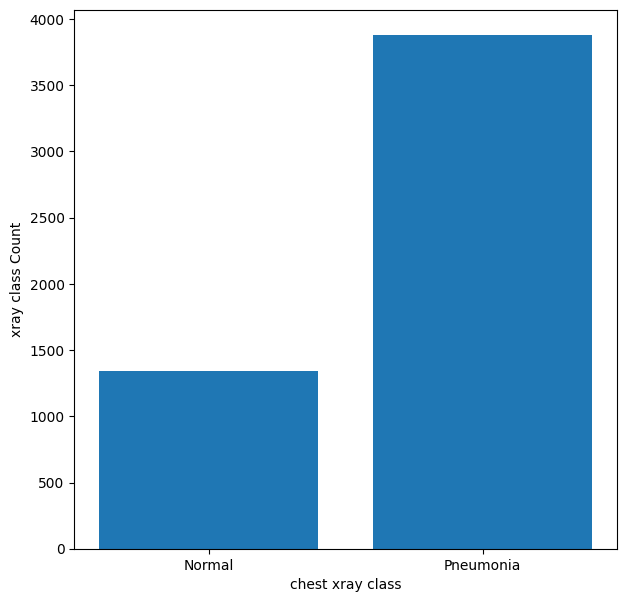

In [39]:
plt.figure(figsize=(7, 7))
plt.bar(classes,train_count)
plt.xlabel("chest xray class")
plt.ylabel("xray class Count")

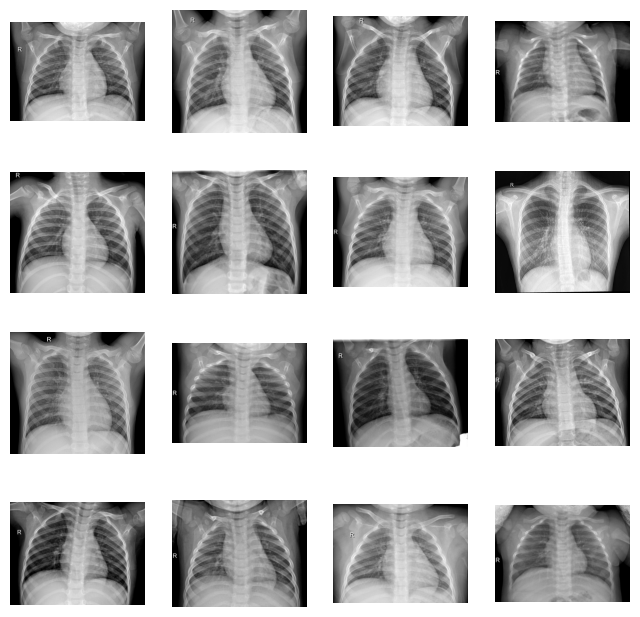

In [40]:
#visualizing normal train images
nrows, ncols = 4, 4
plt.figure(figsize=(8, 8))
for i in range(1, nrows*ncols+1):
  random_image_name  = random.choice(normal_train)
  random_image_path = f"{train_dir}/NORMAL/{random_image_name}"
  image= Image.open(random_image_path)
  plt.subplot(nrows, ncols, i)
  plt.imshow(image, cmap="gray")
  plt.axis("OFF")


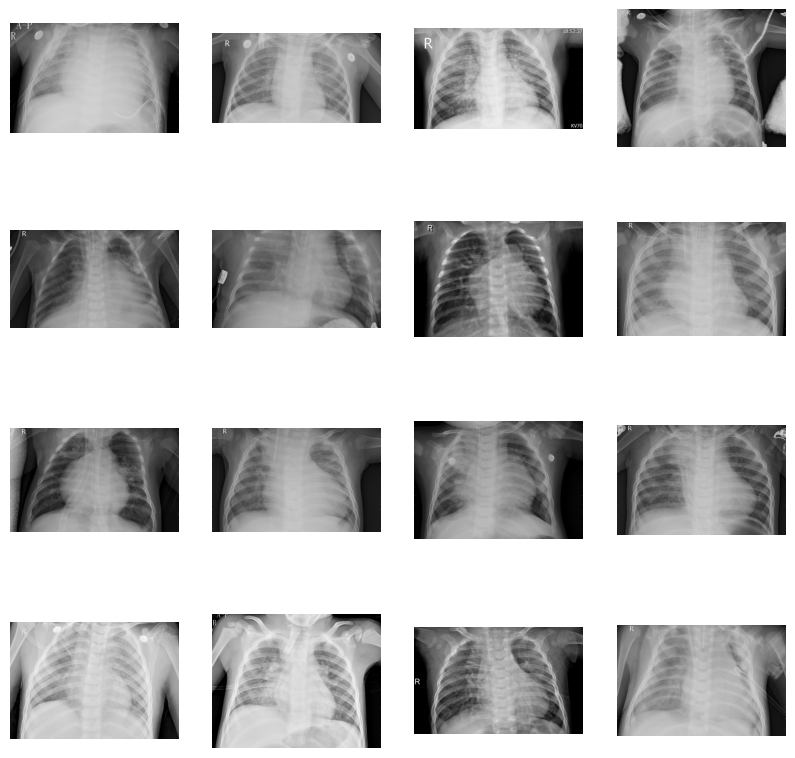

In [41]:
## Visualizing Pneumonia Xray Images
num_cols = 4
num_rows = 4
plt.figure(figsize=(10, 10))
for i in range(1, num_cols*num_rows+1):
  random_image = random.choice(pneumonia_train)
  random_image_name =  f"{train_dir}/PNEUMONIA/{random_image}"
  image = Image.open(random_image_name)
  plt.subplot(num_rows, num_cols, i)
  plt.imshow(image, cmap="gray")
  plt.axis("OFF")






image path: /content/machine-learning-projects/chest-x-ray-classification-cnn/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-0533-0001.jpeg
image format: JPEG
image size: (1924, 1797)


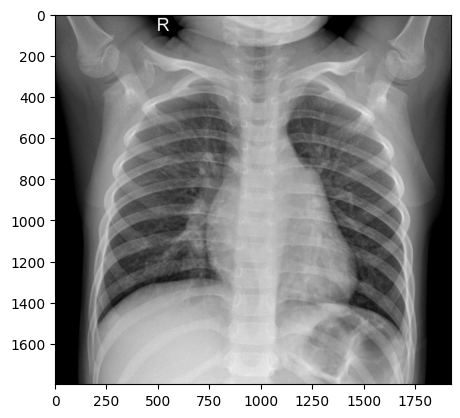

In [42]:
random_normal_xray = random.choice(normal_train)
image_path = f'{train_dir}/NORMAL/{random_normal_xray}'
img = Image.open(image_path)
plt.imshow(img, cmap="gray")
print("image path:", image_path)
print("image format:", img.format)
print("image size:", img.size)

In [45]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(  mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]),

])

train_transforms_two = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(  mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
    ]
)

In [44]:

BATCH_SIZE = 32
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
train_dataset_two = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)


In [46]:
normal_indices = [
    i for i, label in enumerate(train_dataset.targets)
    if label == 0
]

train_dataset_two_normal = Subset(train_dataset_two, normal_indices)


In [48]:
train_dataset = ConcatDataset([
    train_dataset,
    train_dataset_two_normal]
)

In [49]:
print(f'total train loader: {len(train_dataset)}')
print(f'total test loader: {len(test_dataset)}')

total train loader: 6557
total test loader: 624


In [50]:
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

In [ ]:
print(f'classes : { train_dataset.classes}')
print(f'classes tndices: { train_dataset.class_to_idx}')

In [ ]:
### Define Model

class XrayNet(nn.Module):
  def __init__(self, NUM_CLASSES=2):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding="same"),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same"),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3,padding="same"),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2))

    self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
    self.classifier=nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features=256, out_features=128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(in_features=128, out_features=NUM_CLASSES),
    )

  def forward(self, x):
    x= self.features(x)
    x = self.global_pool(x)
    x =torch.flatten(x, 1)
    x =self.classifier(x)
    return x


In [ ]:
def evaluate_model(model, dataloader, metrics, criterion, device):
  model.eval()
  metrics.reset()
  total_loss = 0.0

  with torch.inference_mode():
    for x_batch, y_batch in dataloader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device).unsqueeze(1).to(torch.float32)
      y_logits= model(x_batch)
      y_prob = torch.sigmoid(y_logits)
      y_pred = (y_prob >= 0.5).int()
      metrics.update(y_pred, y_batch)
      loss = criterion(y_logits, y_batch)
      total_loss += loss.item()
  average_loss = total_loss/ len(dataloader)
  average_metrics = metrics.compute()
  return average_loss, average_metrics

def train_model(train_loader, test_loader, model, criterion, optimizer, train_metrics, test_metrics, epochs, device):
  history = {
        "train_loss" : [],
        "train_acc": [],
        "train_precision": [],
        "train_recall": [],

          "test_loss": [],
          "test_acc": [],
          "test_precision": [],
          "test_recall" : []

  }

  best_test_loss = float('inf')
  patience = 5
  epochs_without_improvement = 0
  for epoch in range(epochs):
    train_loss = 0.0
    train_metrics.reset()
    model.train()
    for x_batch, y_batch in train_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device).unsqueeze(1).to(torch.float32)
      y_logits = model(x_batch)
      y_prob = torch.sigmoid(y_logits)
      y_pred = (y_prob >= 0.5).int()
      loss = criterion(y_logits, y_batch)
      train_metrics.update(y_pred, y_batch)
      train_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    train_loss /= len(train_loader)
    average_metric = train_metrics.compute()
    history["train_loss"].append(train_loss)
    history["train_acc"].append(average_metric["accuracy"].item())
    history["train_recall"].append(average_metric["recall"].item())


    test_loss, test_metrics_result = evaluate_model(model=model, dataloader=test_loader, metrics=test_metrics, criterion=criterion, device=device)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_metrics_result["accuracy"].item())
    history["test_recall"].append(test_metrics_result["recall"].item())
    print(f"epoch: {epoch}  train loss: {train_loss} train acc:  {average_metric["accuracy"]} \n test loss: {test_loss}  test accuracy : {test_metrics_result["accuracy"]}")

    if test_loss < best_test_loss:
          best_test_loss = test_loss
          epochs_without_improvement = 0
          torch.save(model, "best_model.pth")
          print("best model saved")
    else:
          epochs_without_improvement +=1
          print(f"no improvement "
          f"{epochs_without_improvement}/{patience}")

    if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break
  return history



In [ ]:
def initialize_weights(module):
  if isinstance(module, nn.Conv2d):
    nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
    if module.bias is not None:
      nn.init.zeros_(module.bias)
  elif isinstance(module, nn.Linear):
    nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
    nn.init.zeros_(module.bias)
  elif isinstance(module, nn.BatchNorm2d):
    nn.init.ones_(module.weight)
    nn.init.zeros_(module.bias)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
def create_metrics():
  metrics = MetricCollection({
      "accuracy": BinaryAccuracy(),
      "recall": BinaryRecall()
  })
  return metrics

In [ ]:
num_normal = sum(
    1 for _, label in train_dataset.samples if label == 0
)

num_pneumonia = sum(
    1 for _, label in train_dataset.samples if label == 1
)

print("NORMAL:", num_normal)
print("PNEUMONIA:", num_pneumonia)

pos_weight_value = num_normal / num_pneumonia

print(pos_weight_value)

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32
).to(device)

In [ ]:
train_metrics = create_metrics().to(device)
test_metrics = create_metrics().to(device)

In [ ]:

model = XrayNet(NUM_CLASSES=1).to(device=device)
model.apply(initialize_weights)
criterion= nn.BCEWithLogitsLoss( pos_weight=pos_weight)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
epochs = 15
history = train_model(
    train_loader=train_loader, test_loader=test_loader, model=model, criterion=criterion, optimizer=optimizer, train_metrics=train_metrics, test_metrics=test_metrics,  epochs=epochs, device=device)


In [ ]:

def plot_history(history):
    epochs_range = range(len(history["train_loss"]))

    fig, axes = plt.subplots(3, 1, figsize=(6, 10))
    axes = axes.flatten()

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker='o')
    axes[0].plot(epochs_range, history["test_loss"], label="Test Loss", marker='o')
    axes[0].set_title("Loss against Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)


    axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", marker='o')
    axes[1].plot(epochs_range, history["test_acc"], label="Test Accuracy", marker='o')
    axes[1].set_title("Accuracy against Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs_range, history["train_recall"], label="train recall", marker="o")
    axes[2].plot(epochs_range, history["test_recall"], label="test recall")
    axes[2].set_title("Recall against Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()


plot_history(history)

- The model perform pretty descent but suffers from slight overfitting
- This is probably due to small dataset and training with custom CNN
- I will run experiment together with hyperparameter tunning to figure out model best parameters
- Transfer learning will be a very goon solution to this classification task since pretrained models already knows how to detect basic features of image

In [ ]:
torch.save(model.state_dict(), "model.pth")

### Transfer Learning with resnet-18

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

In [ ]:
resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


resnet_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
BATCH_SIZE = 32
transfer_train_dataset = datasets.ImageFolder(root=train_dir, transform=resnet_train_transform)
transfer_test_dataset = datasets.ImageFolder(root=test_dir, transform=resnet_test_transform)
transfer_train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
transfer_test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

In [ ]:
weights = ResNet18_Weights.DEFAULT
Resnet_model = resnet18(weights=weights)


In [ ]:
print(Resnet_model.fc)

In [ ]:
in_features = Resnet_model.fc.in_features
Resnet_model.fc=nn.Sequential(
    nn.Linear(in_features=in_features, out_features=1)
).to(device)


In [ ]:
for param in Resnet_model.parameters():
  param.requires_grad = True


# for name, param in Resnet_model.named_parameters():
#   print(name, param.requires_grad)




In [ ]:

optim = torch.optim.Adam(params=model.parameters(), lr=0.00001)
loss_func = nn.BCEWithLogitsLoss()
transfer_train_metrics = create_metrics().to(device)
transfer_test_metrics = create_metrics().to(device)


In [ ]:
transfer_history = train_model(model=Resnet_model, train_loader=transfer_train_loader, test_loader=transfer_test_loader, criterion=loss_func, optimizer=optim, train_metrics=transfer_train_metrics, test_metrics=transfer_test_metrics, epochs=50, device=device)

In [ ]:
plot_history(transfer_history)